## WEEK - 3

## 1. Load Data from MySQL

In [1]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Pravith@20",
    database="retail_project"
)

# Load both tables
sales = pd.read_sql("SELECT * FROM fact_sales", conn)
rfm = pd.read_sql("SELECT * FROM customer_rfm", conn)

print("Data Loaded")

C:\Users\Pravith Kumar J\AppData\Local\Temp\ipykernel_28488\3285405965.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales = pd.read_sql("SELECT * FROM fact_sales", conn)


Data Loaded


C:\Users\Pravith Kumar J\AppData\Local\Temp\ipykernel_28488\3285405965.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rfm = pd.read_sql("SELECT * FROM customer_rfm", conn)


## 2. KPI Creation

In [2]:
# Total Revenue
total_revenue = sales['TotalPrice'].sum()

# Total Orders
total_orders = sales['Invoice'].nunique()

# Total Customers
total_customers = sales['CustomerID'].nunique()

# Average Order Value
avg_order_value = total_revenue / total_orders

print("Revenue:", total_revenue)
print("Orders:", total_orders)
print("Customers:", total_customers)
print("AOV:", avg_order_value)

Revenue: 17743429.160000004
Orders: 36975
Customers: 5881
AOV: 479.8763802569305


## 3. Monthly Revenue Trend

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='InvoiceDate'>

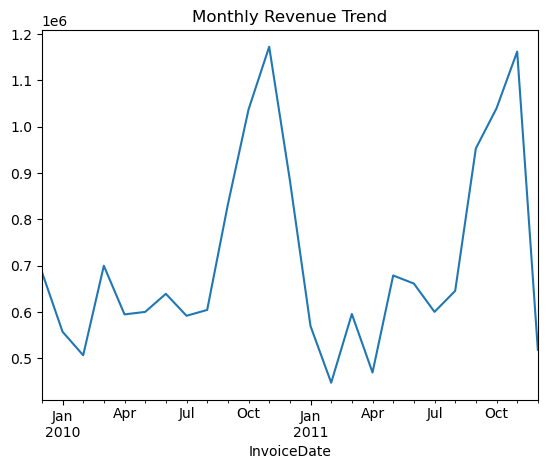

In [3]:
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])

monthly_sales = sales.groupby(
    sales['InvoiceDate'].dt.to_period('M')
)['TotalPrice'].sum()

monthly_sales.plot(kind='line', title="Monthly Revenue Trend")

## 4. Customer Segmentation Visualization

In [5]:
print("Shape:", rfm.shape)
print("Columns:", rfm.columns)

if "Segment" in rfm.columns:
    print("Segment values:", rfm["Segment"].value_counts())

Shape: (0, 9)
Columns: Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM_Score', 'Segment'],
      dtype='object')
Segment values: Series([], Name: count, dtype: int64)


## 5. Country-wise Revenue

<Axes: title={'center': 'Top Customers by Revenue'}, xlabel='CustomerID'>

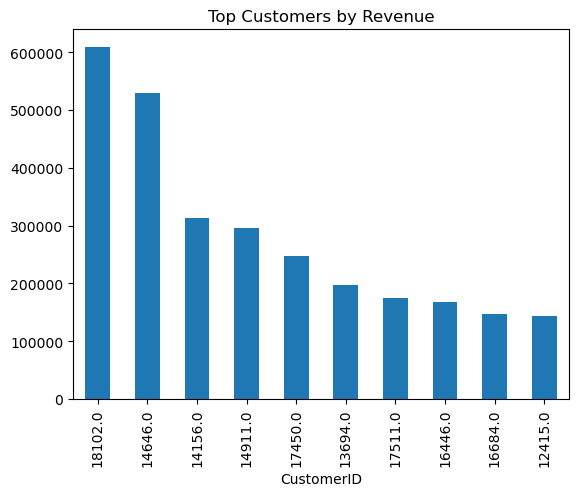

In [6]:
country_sales = sales.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

country_sales.head(10).plot(kind='bar', title="Top Customers by Revenue")

## 6. Top Products

<Axes: title={'center': 'Top Products'}, xlabel='StockCode'>

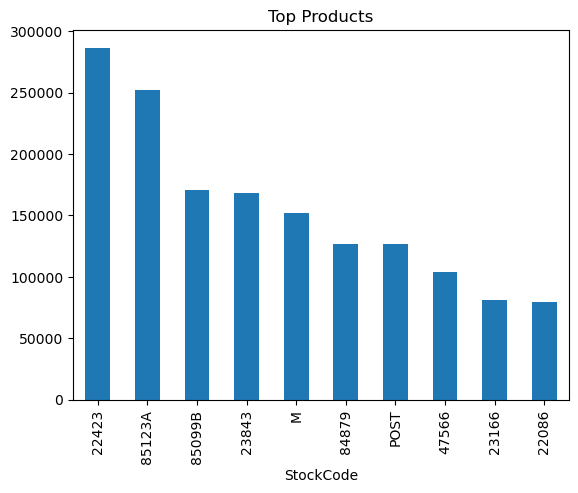

In [7]:
top_products = sales.groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', title="Top Products")

## 7. Export Data for Power BI

In [8]:
sales.to_csv("sales_data.csv", index=False)
rfm.to_csv("rfm_data.csv", index=False)

print("Files ready for Power BI")

Files ready for Power BI
